In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [130]:
df = pd.read_csv("csv_result-.csv")
df.head()

,id,'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent',...,'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','class'
0,1,0,tcp,ftp_data,SF,491,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,2,0,udp,other,SF,146,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,3,0,tcp,private,S0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,4,0,tcp,http,SF,232,8153,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,5,0,tcp,http,SF,199,420,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [131]:
print("Shape of dataset:", df.shape)

Shape of dataset: (125973, 43)


In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             125973 non-null  int64  
 1   'duration'                     125973 non-null  int64  
 2   'protocol_type'                125973 non-null  object 
 3   'service'                      125973 non-null  object 
 4   'flag'                         125973 non-null  object 
 5   'src_bytes'                    125973 non-null  int64  
 6   'dst_bytes'                    125973 non-null  int64  
 7   'land'                         125973 non-null  int64  
 8   'wrong_fragment'               125973 non-null  int64  
 9   'urgent'                       125973 non-null  int64  
 10  'hot'                          125973 non-null  int64  
 11  'num_failed_logins'            125973 non-null  int64  
 12  'logged_in'                   

In [133]:
df.columns = df.columns.str.replace("'", "").str.strip()
df.columns

Index(['id', 'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class'],
      dtype='object')

In [134]:
df.isnull().sum()

id                             0
duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_r

In [135]:
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Duplicate rows: 0


In [136]:
df.describe()

,id,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,125973.000000,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,62987.000000,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,...,182.148945,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240
std,36365.417068,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,...,99.206213,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459
min,1.000000,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31494.000000,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,82.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,62987.000000,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,255.000000,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,94480.000000,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,125973.000000,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [137]:
df['class'].value_counts()

class
normal     67343
anomaly    58630
Name: count, dtype: int64

In [138]:
df.columns

Index(['id', 'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class'],
      dtype='object')

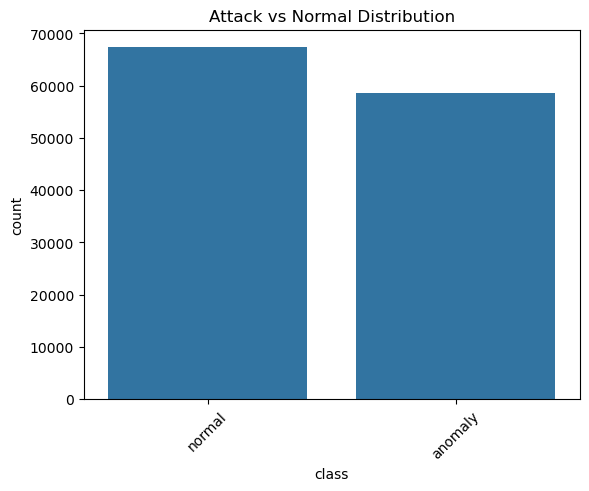

In [140]:
plt.figure()
sns.countplot(x='class', data=df)
plt.xticks(rotation=45)
plt.title("Attack vs Normal Distribution")
plt.show()

In [141]:
df.select_dtypes(include=['object']).columns

Index(['protocol_type', 'service', 'flag', 'class'], dtype='object')

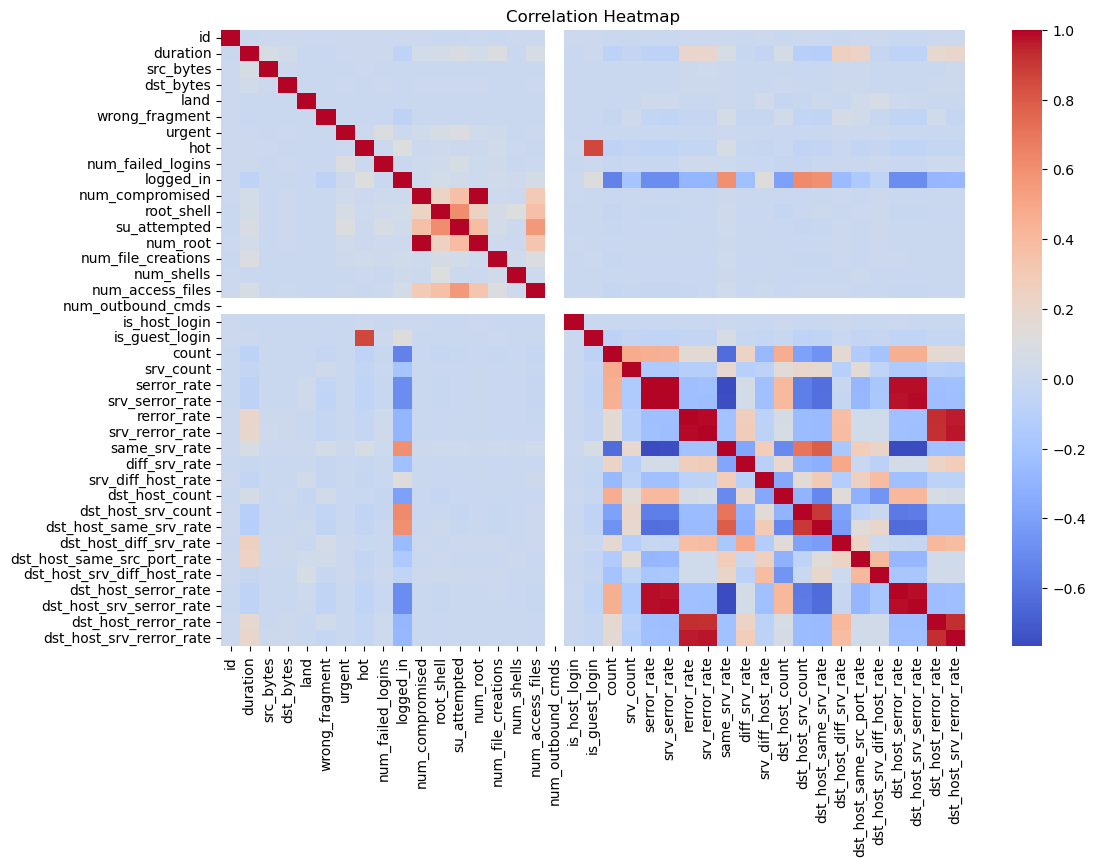

In [142]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

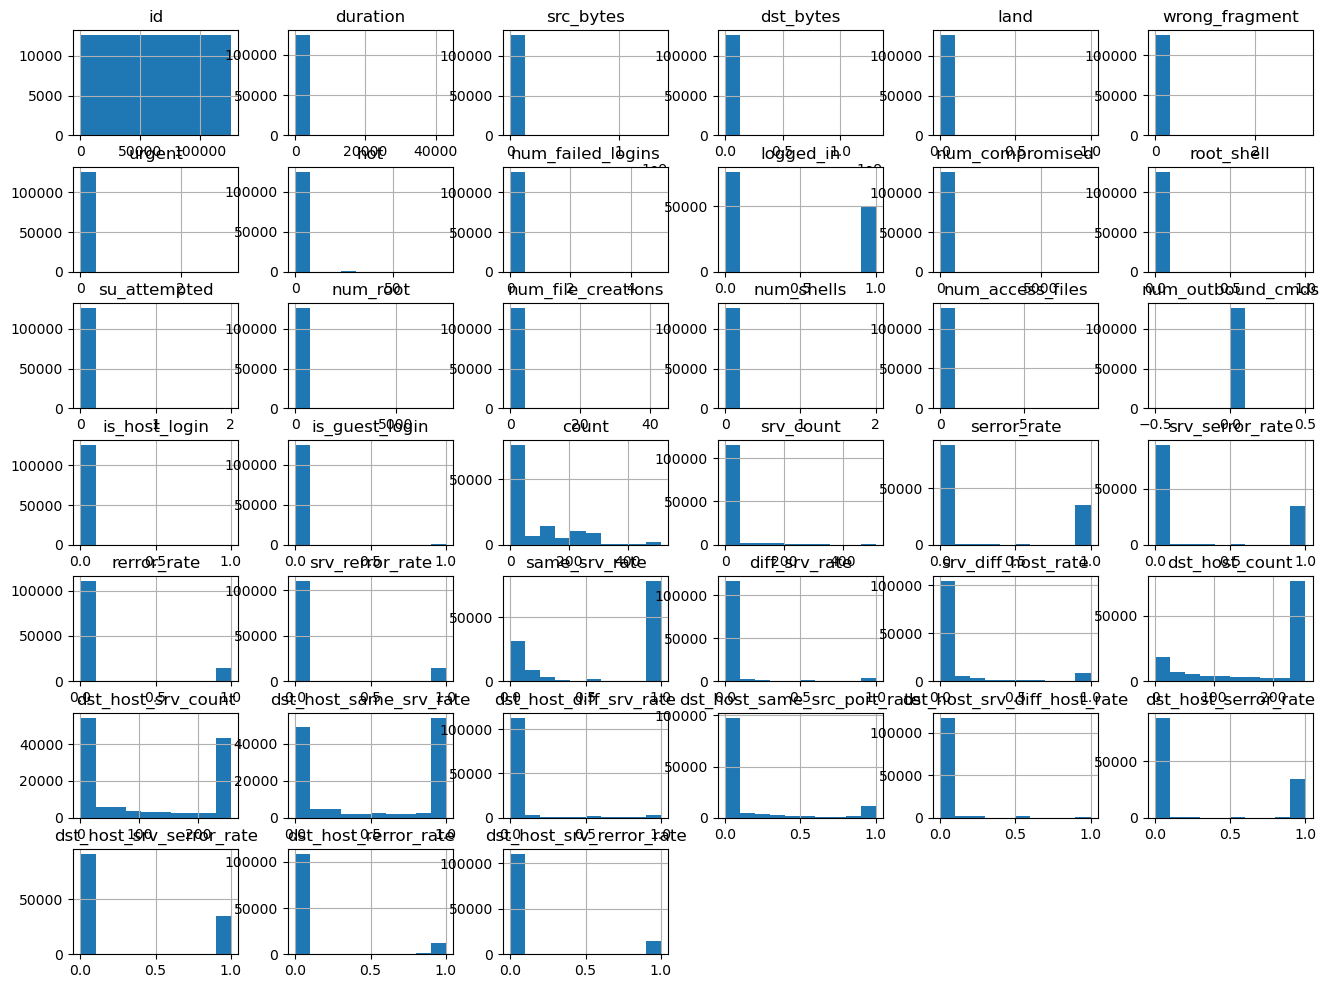

In [143]:
df.hist(figsize=(16,12))
plt.show()

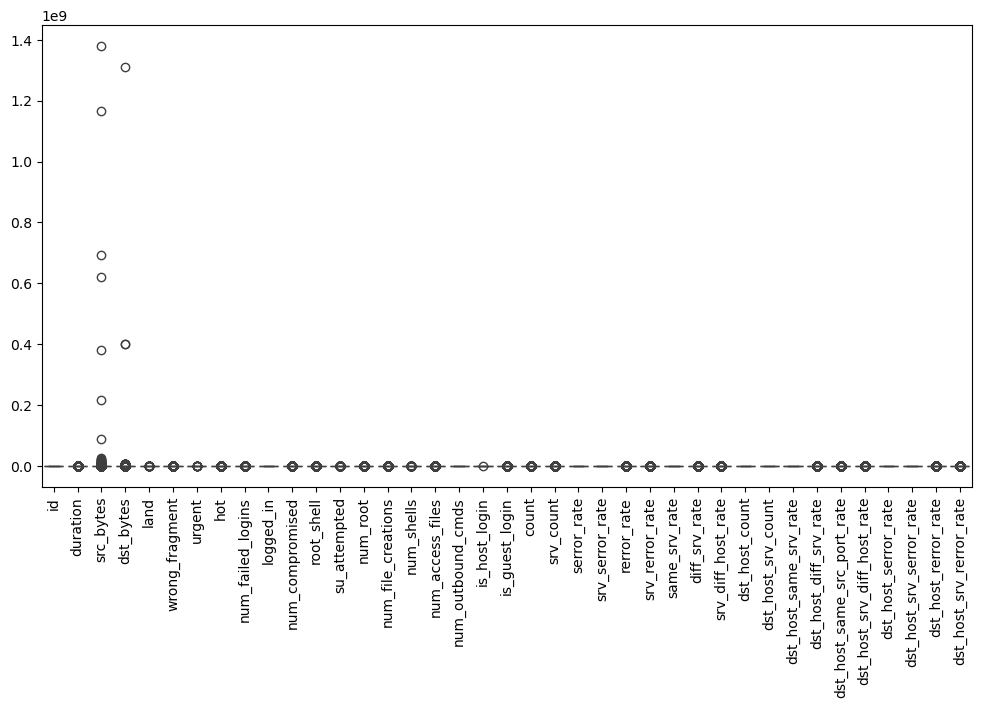

In [144]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.show()

In [145]:
df.columns = df.columns.str.replace("'", "").str.strip().str.lower()
print(df.columns)

Index(['id', 'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class'],
      dtype='object')


In [146]:
le = LabelEncoder()

In [147]:
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
df.head()

,id,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,1,0,1,20,9,491,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1
1,2,0,2,44,9,146,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1
2,3,0,1,49,5,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0
3,4,0,1,24,9,232,8153,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1
4,5,0,1,24,9,199,420,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1


In [149]:
corr = df.corr()['class'].abs().sort_values(ascending=False)
top_features = corr[1:15].index.tolist()   
final_features = top_features + ['class']  
df = df[final_features]
df.head()

,same_srv_rate,dst_host_srv_count,dst_host_same_srv_rate,logged_in,dst_host_srv_serror_rate,dst_host_serror_rate,serror_rate,srv_serror_rate,flag,count,dst_host_count,protocol_type,service,srv_rerror_rate,class
0,1.00,25,0.17,0,0.00,0.00,0.0,0.0,9,2,150,1,20,0.0,1
1,0.08,1,0.00,0,0.00,0.00,0.0,0.0,9,13,255,2,44,0.0,1
2,0.05,26,0.10,0,1.00,1.00,1.0,1.0,5,123,255,1,49,0.0,0
3,1.00,255,1.00,1,0.01,0.03,0.2,0.2,9,5,30,1,24,0.0,1
4,1.00,255,1.00,1,0.00,0.00,0.0,0.0,9,30,255,1,24,0.0,1


In [151]:
df.shape

(125973, 15)

In [152]:
for col in df.columns:
    print(col)

same_srv_rate
dst_host_srv_count
dst_host_same_srv_rate
logged_in
dst_host_srv_serror_rate
dst_host_serror_rate
serror_rate
srv_serror_rate
flag
count
dst_host_count
protocol_type
service
srv_rerror_rate
class


In [153]:
scaler = StandardScaler()

In [155]:
X = df.drop("class", axis=1)
y = df["class"]

In [156]:
X_scaled = scaler.fit_transform(X)

In [157]:
print("Processed data shape:", X_scaled.shape)

Processed data shape: (125973, 14)


In [163]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

In [164]:
df_scaled = pd.concat([X_scaled, y], axis=1)
df_scaled.head()

,same_srv_rate,dst_host_srv_count,dst_host_same_srv_rate,logged_in,dst_host_srv_serror_rate,dst_host_serror_rate,serror_rate,srv_serror_rate,flag,count,dst_host_count,protocol_type,service,srv_rerror_rate,class
0,0.771283,-0.818890,-0.782367,-0.809262,-0.624871,-0.639532,-0.637209,-0.631929,0.751111,-0.717045,-0.324063,-0.124706,-0.686785,-0.374432,1
1,-1.321428,-1.035688,-1.161030,-0.809262,-0.624871,-0.639532,-0.637209,-0.631929,0.751111,-0.620982,0.734343,2.219312,0.781428,-0.374432,1
2,-1.389669,-0.809857,-0.938287,-0.809262,1.618955,1.608759,1.602664,1.605104,-0.736235,0.339648,0.734343,-0.124706,1.087305,-0.374432,0
3,0.771283,1.258754,1.066401,1.235694,-0.602433,-0.572083,-0.189235,-0.184522,0.751111,-0.690846,-1.533670,-0.124706,-0.442083,-0.374432,1
4,0.771283,1.258754,1.066401,1.235694,-0.624871,-0.639532,-0.637209,-0.631929,0.751111,-0.472521,0.734343,-0.124706,-0.442083,-0.374432,1
